Transaction records for Maven Roasters, a fictitious coffee shop operating out of three NYC locations. Dataset includes the transaction date, timestamp and location, along with product-level details.

### Business Question 

How have Maven Roasters sales trended over time?

Which days of the week tend to be busiest, and why do you think that's the case?

What times of day tend to be most popular? Does the same trend hold across all locations?

Which products are sold most and least often? Which drive the most revenue for the business?

In [0]:
%sql
USE `coffee_shop_sales`.`coffee_sales`;

### How have Maven Roasters sales trended over time?

In [0]:
%sql
WITH SALES_TREND AS (
SELECT 
       MONTH(LEFT(transaction_date,10)) AS date_num
      ,MONTHNAME(LEFT(transaction_date,10)) AS transaction_date
      ,ROUND(SUM(transaction_qty * unit_price),2) AS Total_Sales
FROM coffee_shop_sales
GROUP BY date_num 
          ,MONTHNAME(LEFT(transaction_date,10))
ORDER BY date_num
),
calculations AS (
SELECT 
    date_num
    ,transaction_date
    ,total_sales
    ,LAG(Total_Sales) OVER(ORDER BY date_num) AS Previous_Month
    ,total_sales - LAG(Total_Sales) OVER(ORDER BY date_num) AS Sales_Diff
FROM SALES_TREND
)
SELECT 
    transaction_date
    ,total_sales
    ,ROUND((total_sales - previous_month )/previous_month *100,2) AS PCT_Change
FROM calculations;



transaction_date,total_sales,PCT_Change
Jan,81677.74,null
Feb,76145.19,-6.77
Mar,98834.68,29.80
Apr,118941.08,20.34
May,156727.76,31.77
Jun,166485.88,6.23


Databricks visualization. Run in Databricks to view.

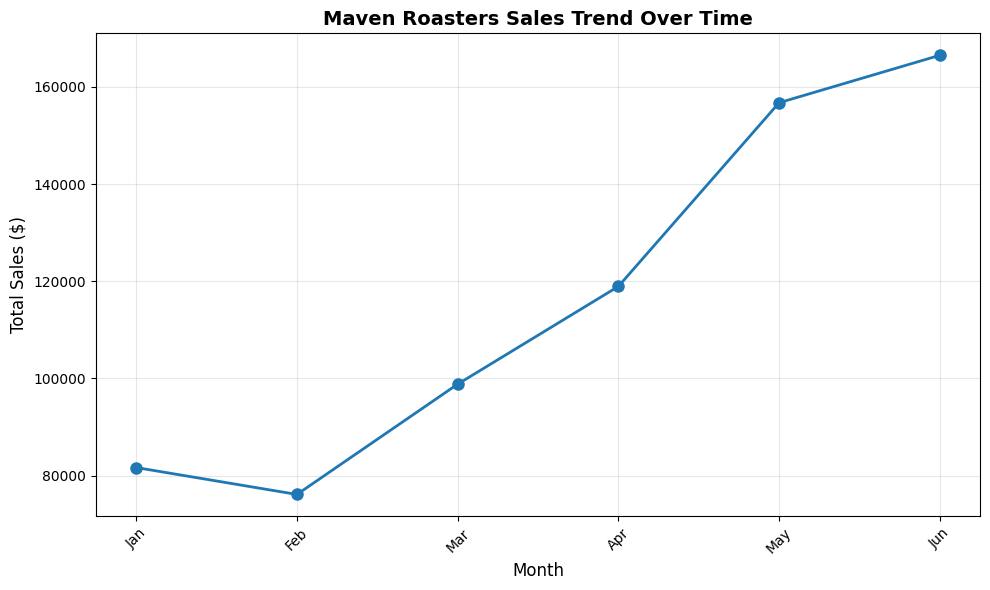


Month-over-Month Growth:
Feb: -6.77%
Mar: 29.80%
Apr: 20.34%
May: 31.77%
Jun: 6.23%


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Get data from previous SQL query
df = _sqldf.toPandas()

# Create line chart
plt.figure(figsize=(10, 6))
plt.plot(df['transaction_date'], df['total_sales'], marker='o', linewidth=2, markersize=8, color='#1f77b4')
plt.title('Maven Roasters Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Show percentage changes
print("\nMonth-over-Month Growth:")
for idx, row in df.iterrows():
    if pd.notna(row['PCT_Change']):
        print(f"{row['transaction_date']}: {row['PCT_Change']:.2f}%")

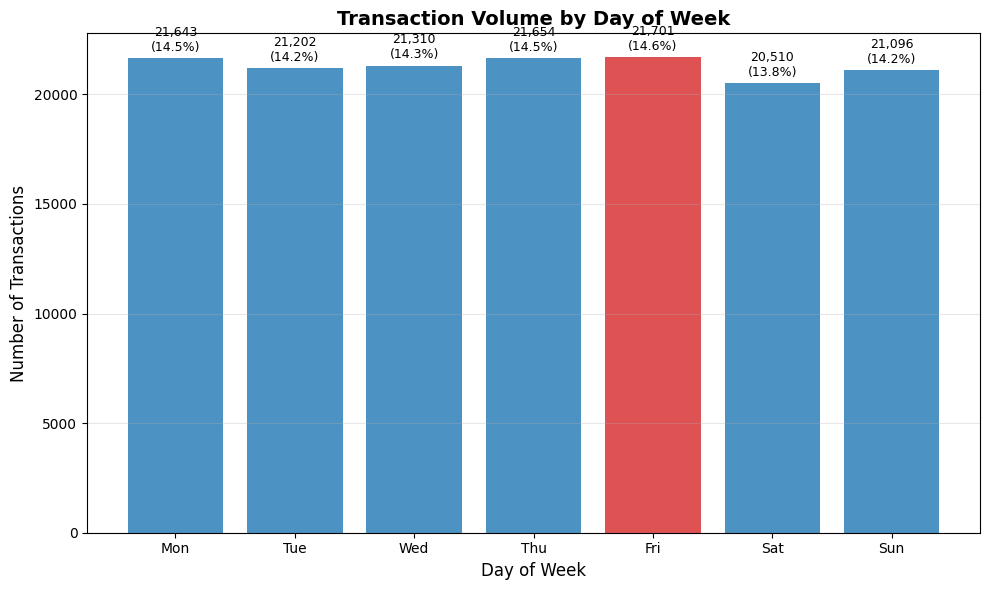

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Get data from previous SQL query
df = _sqldf.toPandas()

# Create bar chart
plt.figure(figsize=(10, 6))
colors = ['#d62728' if rank == 1 else '#1f77b4' for rank in df['RANK']]
plt.bar(df['Day_of_week'], df['Number_of_Transactions'], color=colors, alpha=0.8)
plt.title('Transaction Volume by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for idx, row in df.iterrows():
    plt.text(idx, row['Number_of_Transactions'] + 200, f"{row['Number_of_Transactions']:,}\n({row['Percentage']:.1f}%)", 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

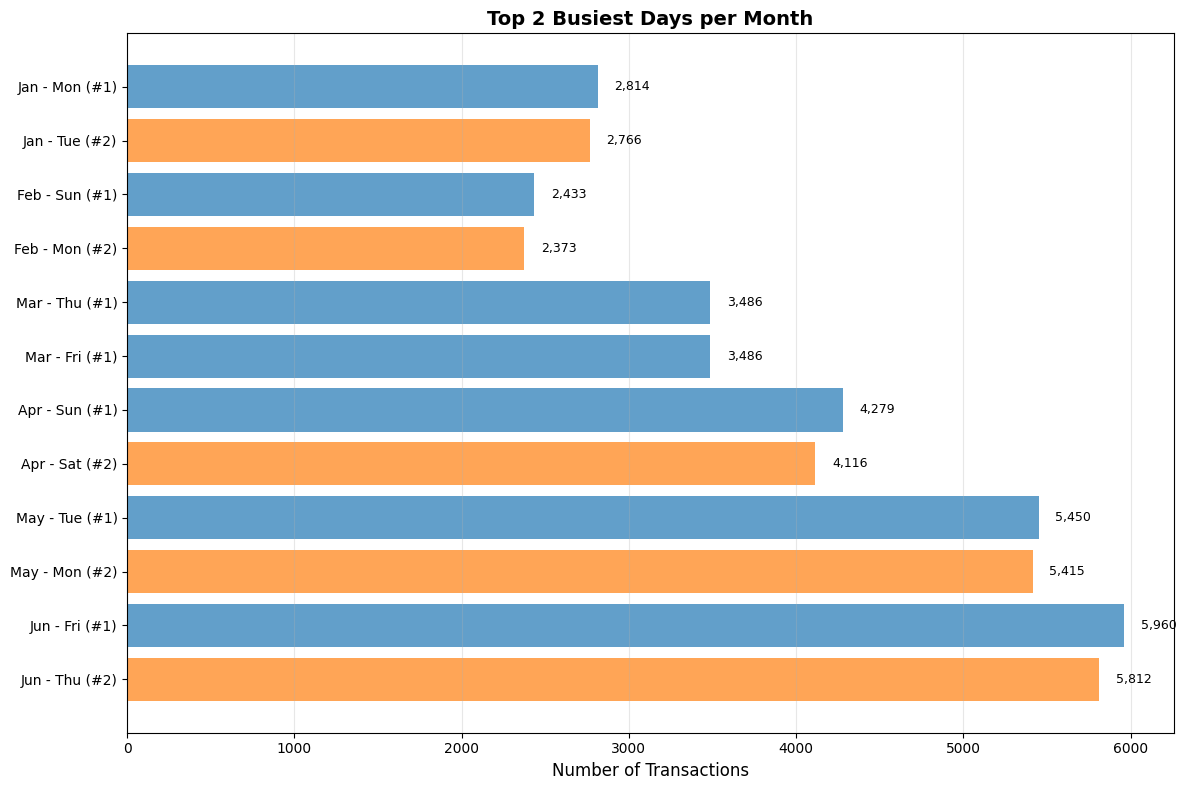

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Get data from previous SQL query
df = _sqldf.toPandas()

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Create labels and colors
labels = [f"{row['Month_of_year']} - {row['Day_of_week']} (#{row['RNK']})" for idx, row in df.iterrows()]
colors = ['#1f77b4' if row['RNK'] == 1 else '#ff7f0e' for idx, row in df.iterrows()]

# Plot
ax.barh(range(len(df)), df['Number_of_Transactions'], color=colors, alpha=0.7)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(labels)
ax.set_xlabel('Number of Transactions', fontsize=12)
ax.set_title('Top 2 Busiest Days per Month', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for idx, (i, row) in enumerate(df.iterrows()):
    ax.text(row['Number_of_Transactions'] + 100, idx, f"{row['Number_of_Transactions']:,}", 
            va='center', fontsize=9)

# Invert y-axis to show January at top
ax.invert_yaxis()

plt.tight_layout()
plt.show()

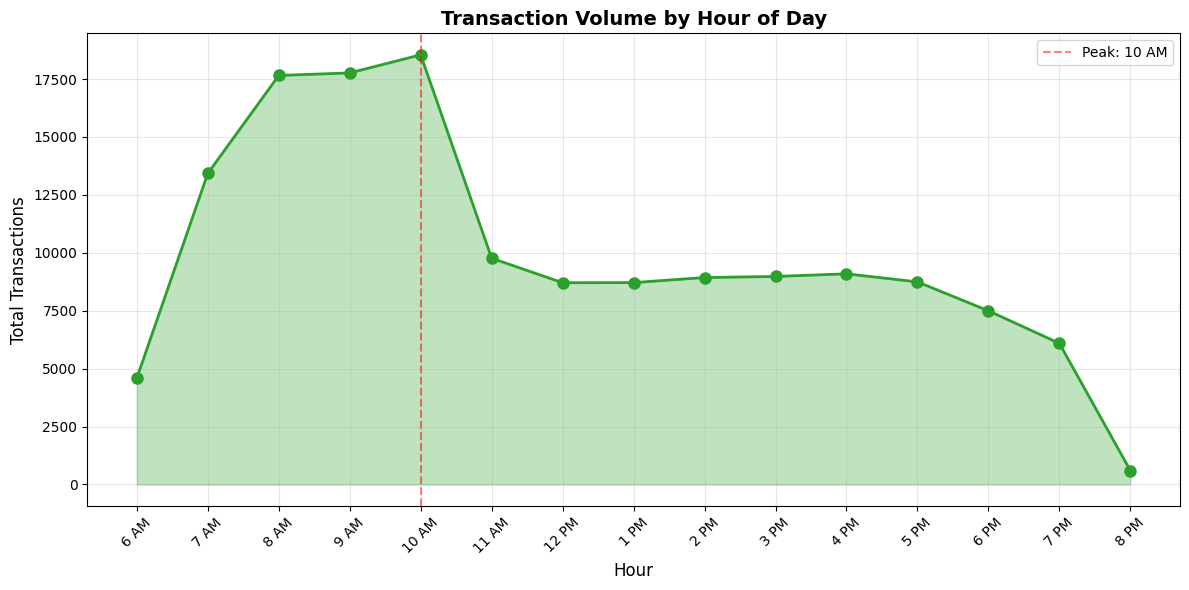

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Get data from previous SQL query
df = _sqldf.toPandas()

# Create line chart
plt.figure(figsize=(12, 6))
plt.plot(df['Hour'], df['Total_Transactions'], marker='o', linewidth=2, markersize=8, color='#2ca02c')
plt.fill_between(df['Hour'], df['Total_Transactions'], alpha=0.3, color='#2ca02c')
plt.title('Transaction Volume by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour', fontsize=12)
plt.ylabel('Total Transactions', fontsize=12)
plt.xticks(df['Hour'], df['Time_of_Day'], rotation=45)
plt.grid(True, alpha=0.3)

# Highlight peak hour
peak_hour = df.loc[df['Total_Transactions'].idxmax()]
plt.axvline(x=peak_hour['Hour'], color='red', linestyle='--', alpha=0.5, label=f'Peak: {peak_hour["Time_of_Day"]}')
plt.legend()

plt.tight_layout()
plt.show()

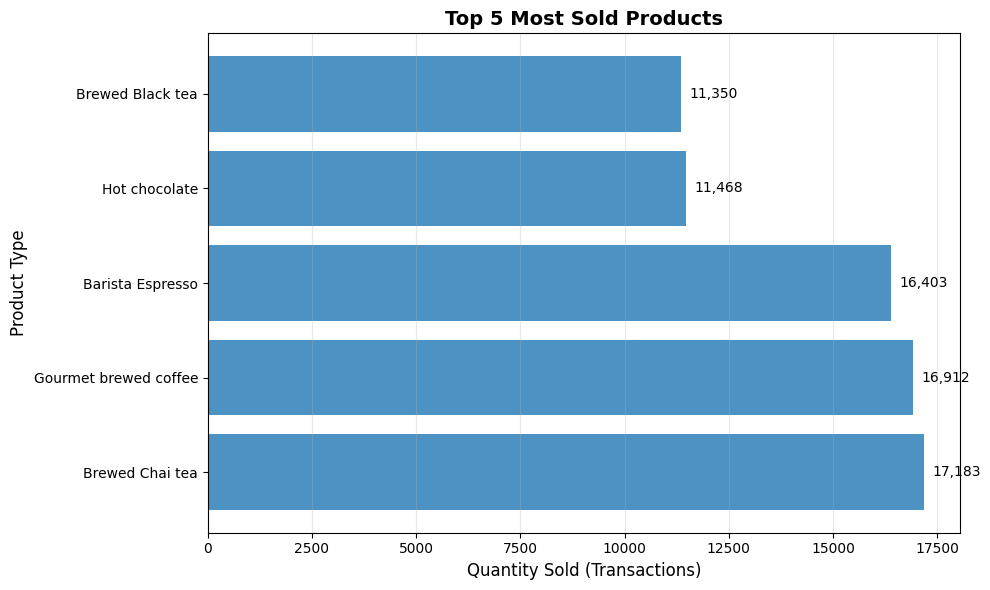

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Get data from previous SQL query
df = _sqldf.toPandas()

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(df['product_type'], df['Quantity_Sold'], color='#1f77b4', alpha=0.8)
plt.title('Top 5 Most Sold Products', fontsize=14, fontweight='bold')
plt.xlabel('Quantity Sold (Transactions)', fontsize=12)
plt.ylabel('Product Type', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for idx, row in df.iterrows():
    plt.text(row['Quantity_Sold'] + 200, idx, f"{row['Quantity_Sold']:,}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

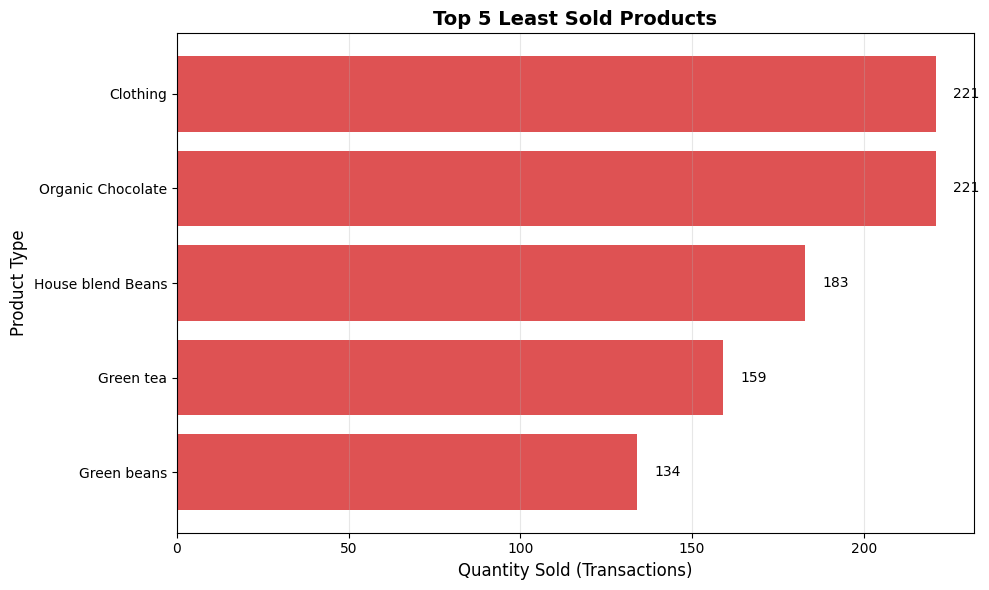

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Get data from previous SQL query
df = _sqldf.toPandas()

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(df['product_type'], df['Quantity_Sold'], color='#d62728', alpha=0.8)
plt.title('Top 5 Least Sold Products', fontsize=14, fontweight='bold')
plt.xlabel('Quantity Sold (Transactions)', fontsize=12)
plt.ylabel('Product Type', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

# Add value labels
for idx, row in df.iterrows():
    plt.text(row['Quantity_Sold'] + 5, idx, f"{row['Quantity_Sold']}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

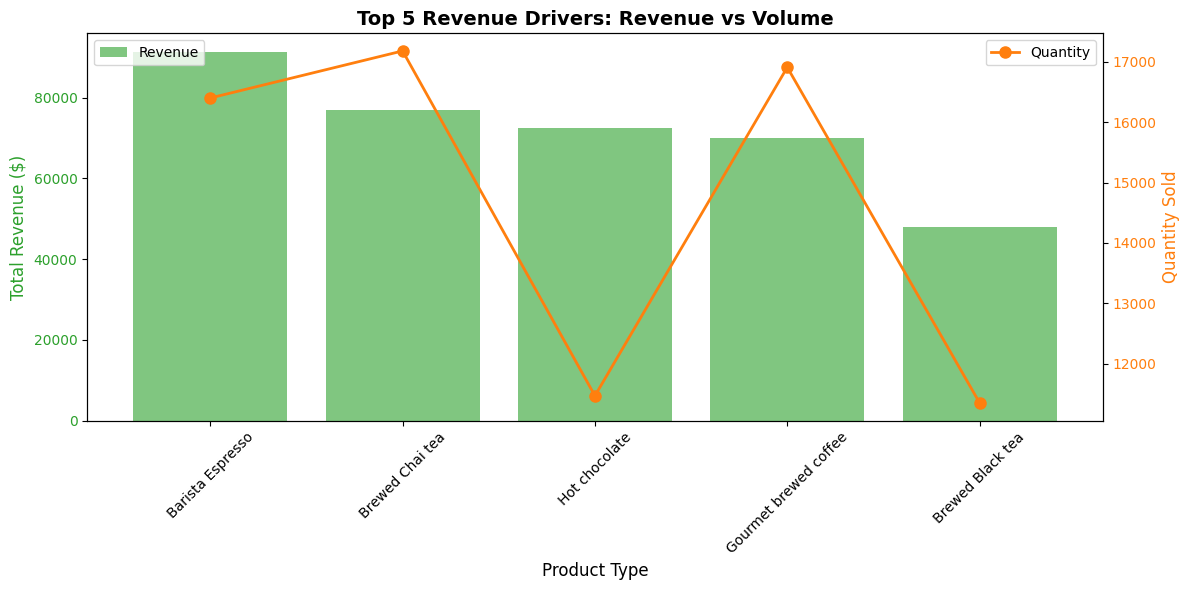


Average Revenue per Transaction:
Barista Espresso: $5.57
Brewed Chai tea: $4.49
Hot chocolate: $6.31
Gourmet brewed coffee: $4.14
Brewed Black tea: $4.22


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Get data from previous SQL query
df = _sqldf.toPandas()

# Create combo chart with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for revenue
color1 = '#2ca02c'
ax1.bar(df['product_type'], df['Total_Revenue'], color=color1, alpha=0.6, label='Revenue')
ax1.set_xlabel('Product Type', fontsize=12)
ax1.set_ylabel('Total Revenue ($)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=45)

# Line chart for quantity on secondary axis
ax2 = ax1.twinx()
color2 = '#ff7f0e'
ax2.plot(df['product_type'], df['Quantity_Sold'], color=color2, marker='o', linewidth=2, markersize=8, label='Quantity')
ax2.set_ylabel('Quantity Sold', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Top 5 Revenue Drivers: Revenue vs Volume', fontsize=14, fontweight='bold')

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Calculate and display average revenue per transaction
df['Avg_Revenue_Per_Transaction'] = df['Total_Revenue'] / df['Quantity_Sold']
print("\nAverage Revenue per Transaction:")
for idx, row in df.iterrows():
    print(f"{row['product_type']}: ${row['Avg_Revenue_Per_Transaction']:.2f}")

Which days of the week tend to be busiest, and why do you think that's the case?

### Overall Pattern

Friday is the busiest day with 21,701 transactions, followed closely by Thursday (21,654) and Monday (21,643)
Saturday is the slowest day with only 20,510 transactions - notably lower than other days
The difference between busiest and slowest is about 1,200 transactions (~5.8%)
Why Friday-Thursday-Monday are busiest:

Weekday work culture: People need their coffee fix during the work week, especially starting Monday and ending the week strong on Thursday/Friday
Friday social factor: Could be more group orders or people treating themselves before the weekend
Monday momentum: People returning to work need that caffeine boost
Saturday dip: People sleep in on weekends, brew coffee at home, or have different routines
Month-by-Month Variation (Cell 8): Your second query reveals that the busiest day varies by month, which is fascinating:

June had the highest single-day volume (Friday with 5,960 transactions)
April's Sunday was unusually busy (4,279) - could indicate special events or seasonal patterns
No consistent pattern - different days win each month, suggesting external factors (weather, holidays, local events) influence traffic
What this tells you about the business:

Staffing should prioritize Thu-Fri-Mon coverage
Saturday might be an opportunity for promotions to drive traffic
The monthly variation suggests you should analyze specific dates for holidays/events that drove Sunday/Tuesday spikes

In [0]:
%sql
SELECT 
    WEEKDAY(transaction_date) + 1 AS NUM_of_Week,
    DAYNAME(transaction_date) AS Day_of_week,
    COUNT(*) AS Number_of_Transactions,
    ROUND(
        COUNT(*) / SUM(COUNT(*)) OVER() * 100,
        2
    ) AS Percentage,
    RANK() OVER (ORDER BY COUNT(*) DESC) AS RANK
FROM coffee_shop_sales
GROUP BY 
    WEEKDAY(transaction_date),
    DAYNAME(transaction_date)
ORDER BY NUM_of_Week;




NUM_of_Week,Day_of_week,Number_of_Transactions,Percentage,RANK
1,Mon,21643,14.51,3
2,Tue,21202,14.22,5
3,Wed,21310,14.29,4
4,Thu,21654,14.52,2
5,Fri,21701,14.55,1
6,Sat,20510,13.75,7
7,Sun,21096,14.15,6


Databricks visualization. Run in Databricks to view.

In [0]:
%sql
WITH aggregate_transcations AS(
SELECT 
MONTH(transaction_date) AS MonthNum
,MONTHNAME(transaction_date) AS Month_of_year
,dayofweek(transaction_date) AS Day_of_week_num
,DAYNAME(transaction_date) AS Day_of_week
,COUNT(*) AS Number_of_Transactions
FROM coffee_shop_sales
GROUP BY 
    MonthNum
    ,Month_of_year
    ,Day_of_week_num
    ,Day_of_week
),
RANKING AS (
SELECT 
MonthNum
,Month_of_year
,Day_of_week_num
,Day_of_week
,Number_of_Transactions
,Rank() OVER(PARTITION BY Month_of_year ORDER BY Number_of_Transactions DESC) AS RNK
FROM aggregate_transcations
) 
SELECT 
    *
    
FROM RANKING
WHERE RNK <= 2
ORDER BY MonthNum;

MonthNum,Month_of_year,Day_of_week_num,Day_of_week,Number_of_Transactions,RNK
1,Jan,3,Tue,2766,2
1,Jan,2,Mon,2814,1
2,Feb,1,Sun,2433,1
2,Feb,2,Mon,2373,2
3,Mar,6,Fri,3486,1
3,Mar,5,Thu,3486,1
4,Apr,7,Sat,4116,2
4,Apr,1,Sun,4279,1
5,May,2,Mon,5415,2
5,May,3,Tue,5450,1


Databricks visualization. Run in Databricks to view.

What times of day tend to be most popular?

### Time of Day Patterns:

Clear Morning Rush (7-10 AM): Peak period with 10 AM hitting 18,545 transactions - the single busiest hour.
Early Morning Surge: 7-9 AM is extremely strong (13K-18K each hour) - classic coffee shop commute pattern.

### Business Insights:

Staffing priority: 7-10 AM is critical - need maximum coverage.
Prep timing: Highest inventory should be ready by 7 AM.

In [0]:
%sql
SELECT 
      HOUR(RIGHT(TRY_CAST(transaction_time AS timestamp),9)) AS Hour
      ,CASE 
        WHEN HOUR(RIGHT(TRY_CAST(transaction_time AS timestamp),9)) = 0 THEN '12 AM'
        WHEN HOUR(RIGHT(TRY_CAST(transaction_time AS timestamp),9)) BETWEEN 1 AND 11 THEN CONCAT(HOUR(RIGHT(TRY_CAST(transaction_time AS timestamp),9)), ' AM')
        WHEN HOUR(RIGHT(TRY_CAST(transaction_time AS timestamp),9)) = 12 THEN '12 PM'
        WHEN HOUR(RIGHT(TRY_CAST(transaction_time AS timestamp),9)) BETWEEN 13 AND 23 THEN CONCAT(HOUR(RIGHT(TRY_CAST(transaction_time AS timestamp),9)) - 12, ' PM')
        ELSE NULL
      END AS Time_of_Day 
    ,COUNT(*) AS Total_Transactions
FROM coffee_shop_sales
GROUP BY Time_of_Day, Hour
ORDER BY Hour ASC;


Hour,Time_of_Day,Total_Transactions
6,6 AM,4594
7,7 AM,13428
8,8 AM,17654
9,9 AM,17764
10,10 AM,18545
11,11 AM,9766
12,12 PM,8708
13,1 PM,8714
14,2 PM,8933
15,3 PM,8979


Databricks visualization. Run in Databricks to view.

Which products are sold most and least often? Which drive the most revenue for the business?

### Product Performance Analysis:

### Most Sold:
Brewed Chai tea (17,183) - volume leader
Gourmet brewed coffee (16,912)
Barista Espresso (16,403)

### Least Sold:
Green beans (134) - 128x less than top seller
Green tea (159)
House blend Beans (183)

### Revenue Drivers:
Barista Espresso - $91,406 (despite being #3 in volume)
Brewed Chai tea - $77,082
Hot chocolate - $72,416


**Key Insight: Value Arbitrage**
Barista Espresso generates 19% more revenue than Chai tea despite 5% fewer transactions.

Espresso avg: $5.57/transaction
Chai avg: $4.49/transaction

24% price premium
Hot chocolate is the margin champion: $6.31/transaction with half the volume of leaders

Strategic Actions:
Discontinue/Clearance:

In [0]:
%sql

-- Top 5 Products Sold the Most 
SELECT 
product_type
,COUNT(product_id) AS Quantity_Sold 
FROM coffee_shop_sales
GROUP BY 
        product_type
ORDER BY Quantity_Sold DESC
LIMIT 5;

product_type,Quantity_Sold
Brewed Chai tea,17183
Gourmet brewed coffee,16912
Barista Espresso,16403
Hot chocolate,11468
Brewed Black tea,11350


Databricks visualization. Run in Databricks to view.

In [0]:
%sql
-- Top 5 products with least sales 
SELECT 
product_type
,COUNT(product_id) AS Quantity_Sold 
FROM coffee_shop_sales
GROUP BY 
        product_type
ORDER BY Quantity_Sold ASC
LIMIT 5;

product_type,Quantity_Sold
Green beans,134
Green tea,159
House blend Beans,183
Organic Chocolate,221
Clothing,221


Databricks visualization. Run in Databricks to view.

In [0]:
%sql
-- Top 5 products that drive the most revenue for the business 
SELECT 
 product_type
,COUNT(product_id) AS Quantity_Sold 
,ROUND(SUM(transaction_qty * unit_price),0) AS Total_Revenue
FROM coffee_shop_sales
GROUP BY 
        product_type
ORDER BY Total_Revenue DESC
LIMIT 5;

product_type,Quantity_Sold,Total_Revenue
Barista Espresso,16403,91406
Brewed Chai tea,17183,77082
Hot chocolate,11468,72416
Gourmet brewed coffee,16912,70035
Brewed Black tea,11350,47932


Databricks visualization. Run in Databricks to view.